<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">

<h1 style="margin-bottom:0;"><b> Machine Learning II </b></h1>

<h3><b> Exploratory Data Analysis and Pre-Processing </b></h3>


<div style="background-color:#EFF5FF; padding:15px; border-radius:10px;">

**Table of Contents**



<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b> 1 Imports and Data Loading </b></h3>

In [1]:
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pylab import rcParams
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
import warnings

import utils_eda as utils
warnings.filterwarnings("ignore")

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b> 1.1 Data Analysis </b></h3>

In [2]:
path = "/Users/franciscateixeira/Documents/ML/CostumerSegP_MLII/datasets/customer_info.csv"
ci = pd.read_csv(path, index_col='customer_id')

In [3]:
pd.set_option('display.max_columns', None)
ci.sort_index(inplace = True)
display(ci.head())

,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
customer_id,,,,,,,,,,,,,,,,,,,,,,,,
3,Bsc. Crystal Kitchens,female,02/12/1970 01:36 PM,1.0,1.0,1.0,3.0,11731.0,4553.0,NaN,373.0,323.0,177.0,28.0,213.0,552.0,256.0,384.0,189.0,0.631599,2020.0,1.0,38.794428,-9.215739
4,Bsc. Glenda Bauman,female,11/13/1975 06:58 PM,1.0,0.0,0.0,2.0,13694.0,963.0,NaN,2012.0,533.0,95.0,43.0,15.0,1880.0,333.0,665.0,130.0,0.149890,2013.0,1.0,38.751711,-9.179611
5,Msc. Antonio Campbell,male,09/10/1971 10:07 AM,0.0,0.0,NaN,2.0,12407.0,0.0,11.0,555.0,101.0,118.0,1265.0,273.0,507.0,101.0,222.0,81.0,0.069126,2005.0,NaN,38.780678,-9.160656
7,John Kelling,male,10/23/1982 11:20 AM,0.0,0.0,2.0,1.0,7493.0,1105.0,18.0,84.0,757.0,1133.0,972.0,1083.0,485.0,1656.0,184.0,92.0,0.253609,2021.0,1.0,38.739548,-9.148679
8,Arthur Dematteo,male,08/04/1969 10:22 PM,0.0,0.0,3.0,1.0,9187.0,10841.0,17.0,380.0,592.0,718.0,1068.0,1015.0,297.0,1258.0,441.0,6.0,0.186569,2021.0,1.0,38.733071,-9.188188


In [4]:
display(ci.tail())

,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
customer_id,,,,,,,,,,,,,,,,,,,,,,,,
39996,Joshua Howard,male,05/16/1973 02:04 PM,0.0,0.0,2.0,1.0,475.0,13488.0,NaN,190.0,573.0,994.0,1020.0,1154.0,62.0,1598.0,366.0,162.0,0.261352,2014.0,NaN,38.742306,-9.163971
39997,Anthony Hines,male,05/10/1955 01:19 AM,1.0,0.0,1.0,1.0,8430.0,14408.0,21.0,291.0,497.0,1417.0,1323.0,602.0,220.0,2105.0,227.0,97.0,0.143479,2014.0,NaN,38.748505,-9.193445
39998,Edna Hasselman,female,05/15/1945 11:09 PM,1.0,1.0,0.0,4.0,8029.0,1480.0,14.0,1600.0,494.0,117.0,307.0,NaN,1719.0,89.0,258.0,206.0,0.181917,2012.0,NaN,38.776003,-9.137943
39999,George Kramer,male,05/25/1951 09:02 PM,1.0,1.0,1.0,6.0,8364.0,3114.0,11.0,596.0,303.0,661.0,NaN,113.0,410.0,NaN,225.0,385.0,0.807259,2017.0,NaN,38.736034,-9.145235
40000,Sammie Wright,female,07/09/1990 10:27 AM,0.0,1.0,1.0,1.0,4774.0,2127.0,7.0,701.0,387.0,126.0,816.0,729.0,1331.0,323.0,239.0,102.0,0.252563,2017.0,NaN,38.758936,-9.145988


In [5]:
display(ci.info(memory_usage="deep"))

<class 'pandas.core.frame.DataFrame'>
Index: 33038 entries, 3 to 40000
Data columns (total 24 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   customer_name                            33038 non-null  object 
 1   customer_gender                          33038 non-null  object 
 2   customer_birthdate                       32873 non-null  object 
 3   kids_home                                32708 non-null  float64
 4   teens_home                               32708 non-null  float64
 5   number_complaints                        32377 non-null  float64
 6   distinct_stores_visited                  32708 non-null  float64
 7   lifetime_spend_groceries                 33038 non-null  float64
 8   lifetime_spend_electronics               32377 non-null  float64
 9   typical_hour                             32377 non-null  float64
 10  lifetime_spend_vegetables                32377 non-

None

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b> 1.2 Duplicate Rows Analysis </b></h3>

In [6]:
duplicate_rows = ci[ci.duplicated()]
display(duplicate_rows.head())

,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
customer_id,,,,,,,,,,,,,,,,,,,,,,,,


see if there is duplicated individuals

In [7]:
ci[ci[['customer_name', 'customer_birthdate']].duplicated()]

,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
customer_id,,,,,,,,,,,,,,,,,,,,,,,,


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b> 1.3 Missing Values Analysis </b></h3>

In [8]:
missing_df = utils.get_missing_percent(ci)

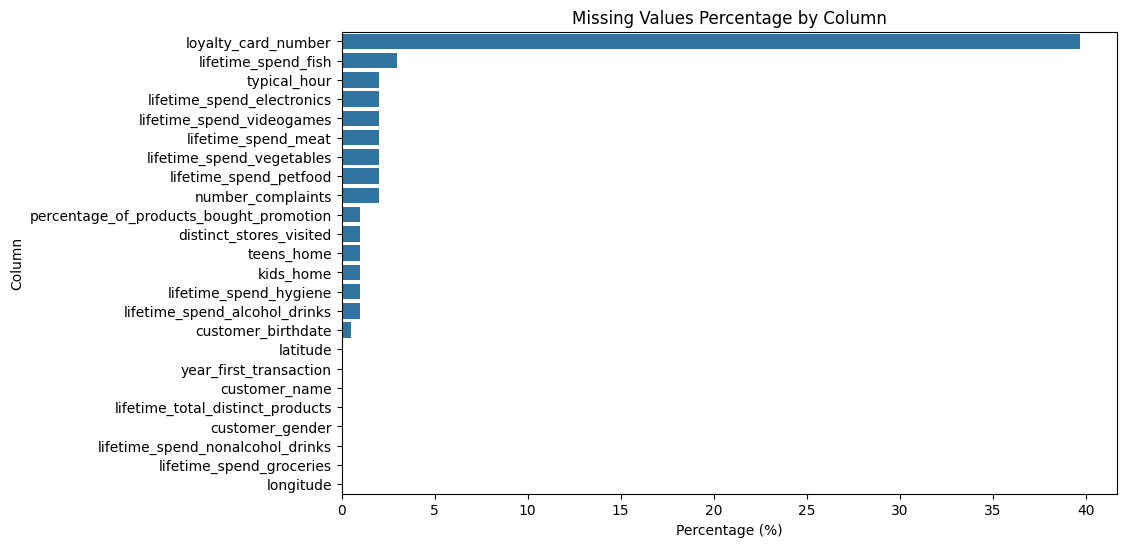

In [9]:
plt.figure(figsize=(10,6))
sns.barplot(x='Missing_Percent', y='Column', data=missing_df)
plt.title("Missing Values Percentage by Column")
plt.xlabel("Percentage (%)")
plt.ylabel("Column")
plt.show()

In [10]:
high_missing = missing_df[missing_df['Missing_Percent'] > 30]
display(high_missing)

,Column,Missing_Percent
21,loyalty_card_number,39.67


In [11]:
print(f"Unique Values of column loyalty_card_number: {ci['loyalty_card_number'].nunique()}")

Unique Values of column loyalty_card_number: 1


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b> 1.4 Define Numerical and Categorical Columns</b></h3>

In [12]:
numerical_cols = ci.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = ci.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Numerical columns ({len(numerical_cols)}):")
display(pd.DataFrame(numerical_cols, columns=['Numerical Columns']))

print(f"Categorical columns ({len(categorical_cols)}):")
display(pd.DataFrame(categorical_cols, columns=['Categorical Columns']))

Numerical columns (21):


,Numerical Columns
0,kids_home
1,teens_home
2,number_complaints
3,distinct_stores_visited
4,lifetime_spend_groceries
5,lifetime_spend_electronics
6,typical_hour
7,lifetime_spend_vegetables
8,lifetime_spend_nonalcohol_drinks
9,lifetime_spend_alcohol_drinks


Categorical columns (3):


,Categorical Columns
0,customer_name
1,customer_gender
2,customer_birthdate


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b> 1.4.1 Finds in Categorical Columns</b></h3>

In [13]:
ci[["customer_name"]]

,customer_name
customer_id,
3,Bsc. Crystal Kitchens
4,Bsc. Glenda Bauman
5,Msc. Antonio Campbell
7,John Kelling
8,Arthur Dematteo
...,...
39996,Joshua Howard
39997,Anthony Hines
39998,Edna Hasselman


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b> 1.5 Statistical Summary</b></h3>

In [14]:
print("Statistical summary for numerical columns:")
ci[numerical_cols].describe().T

Statistical summary for numerical columns:


,count,mean,std,min,25%,50%,75%,max
kids_home,32708.0,1.116118,1.150186,0.000000,0.000000,1.000000,1.000000,8.000000
teens_home,32708.0,0.898893,0.962924,0.000000,0.000000,1.000000,1.000000,6.000000
number_complaints,32377.0,0.930846,0.894658,0.000000,0.000000,1.000000,1.000000,7.000000
distinct_stores_visited,32708.0,3.167941,1.674114,1.000000,2.000000,3.000000,4.000000,10.000000
lifetime_spend_groceries,33038.0,16306.227798,11985.903518,0.000000,8647.000000,13002.500000,20807.000000,104670.000000
lifetime_spend_electronics,32377.0,2763.080088,3453.191495,0.000000,579.000000,1470.000000,3745.000000,35299.000000
typical_hour,32377.0,12.659388,4.854708,6.000000,8.000000,12.000000,16.000000,23.000000
lifetime_spend_vegetables,32377.0,727.223801,654.633087,0.000000,224.000000,471.000000,1074.000000,3337.000000
lifetime_spend_nonalcohol_drinks,33038.0,464.352776,275.767976,0.000000,241.000000,421.000000,640.000000,2180.000000
lifetime_spend_alcohol_drinks,32708.0,622.144185,517.744320,0.000000,201.000000,483.000000,891.250000,3704.000000


! aqui a percentage... tem valores negativos como minimos e nao pode


In [15]:
condition = (ci['percentage_of_products_bought_promotion'] < 0.0) | (ci['percentage_of_products_bought_promotion'] > 1.0)
rows_wrong = ci[condition]
display(rows_wrong.head())

,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
customer_id,,,,,,,,,,,,,,,,,,,,,,,,
12,Phd. Dorothy Pacheco,female,05/19/2000 03:02 AM,0.0,0.0,0.0,2.0,9281.0,254.0,18.0,125.0,60.0,1549.0,139.0,598.0,673.0,71.0,64.0,29.0,-0.131176,2018.0,NaN,38.748616,-9.167756
35,Bsc. Thomas King,male,08/08/1979 05:25 AM,NaN,1.0,0.0,2.0,37795.0,2130.0,8.0,636.0,102.0,310.0,890.0,844.0,842.0,42.0,524.0,212.0,-0.025524,2011.0,1.0,38.762036,-9.158847
37,Phd. Alonzo Crossan,male,09/29/2000 07:54 PM,1.0,1.0,0.0,5.0,25539.0,1089.0,7.0,907.0,1681.0,896.0,1153.0,962.0,1205.0,344.0,329.0,330.0,-0.184820,2028.0,1.0,38.729700,-9.196585
81,Phd. Denise Allard,female,03/18/1992 06:34 PM,2.0,0.0,2.0,1.0,6273.0,430.0,6.0,208.0,291.0,525.0,539.0,804.0,707.0,121.0,320.0,91.0,-0.217805,2020.0,1.0,38.748092,-9.155615
87,Phd. Milagro Amelung,female,09/03/1977 11:26 AM,1.0,1.0,1.0,3.0,28825.0,2948.0,15.0,459.0,687.0,716.0,884.0,1495.0,1314.0,161.0,916.0,337.0,-0.022180,2008.0,1.0,38.776791,-9.146792


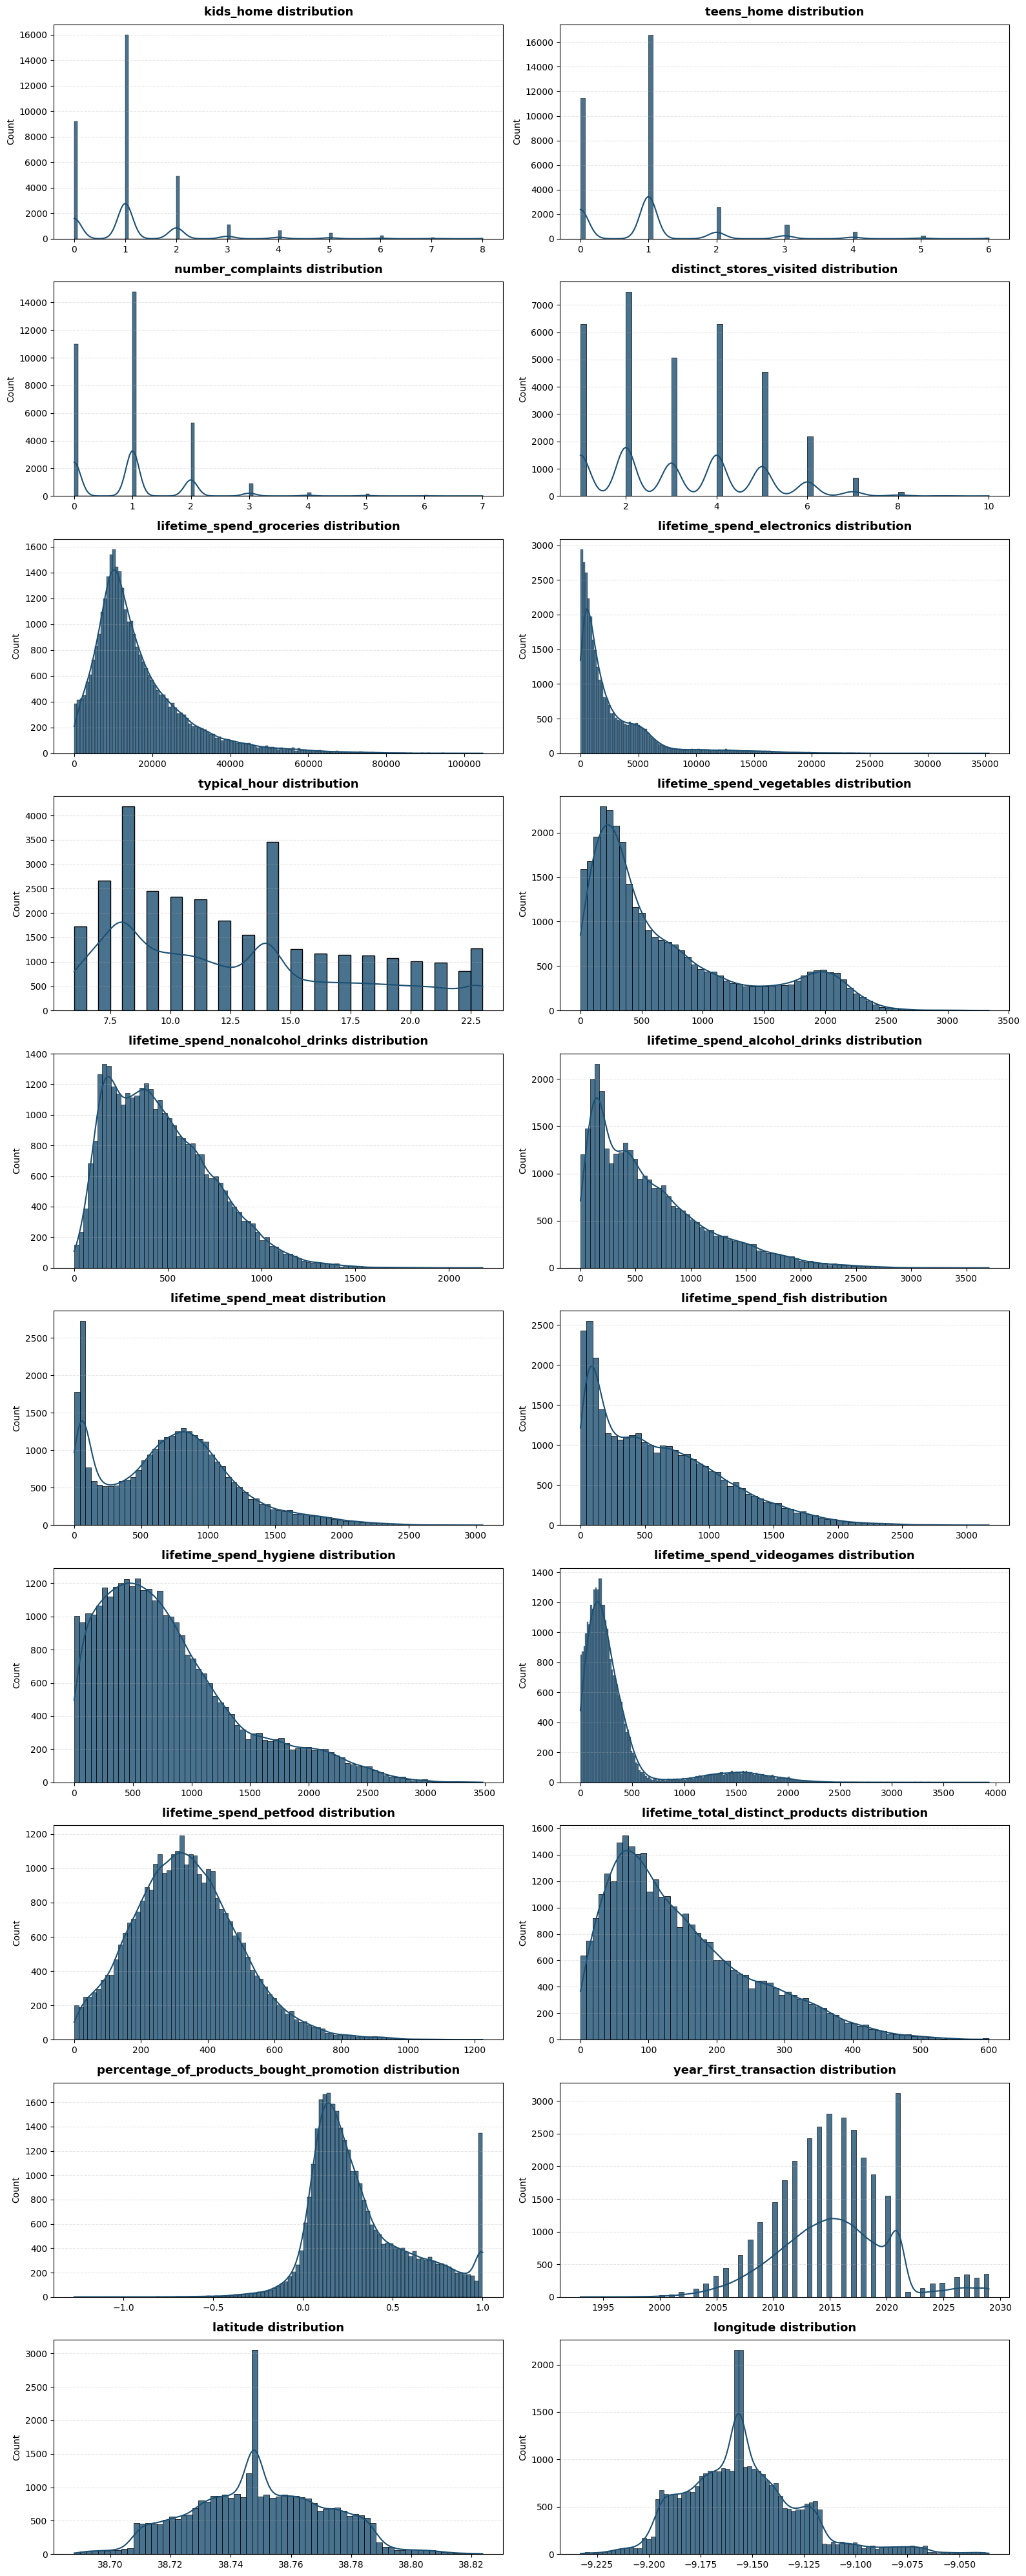

In [16]:
CUSTOM_BLUE = "#1B4F72"

vars_to_plot = list(ci.select_dtypes(include=np.number).columns)
for col in ['loyalty_card_number', 'customer_id', 'customer_loyalty_flag']:
    if col in vars_to_plot: vars_to_plot.remove(col)

fig, axes = plt.subplots(nrows=(len(vars_to_plot) + 1) // 2, ncols=2, figsize=(16, len(vars_to_plot) * 2))
axes = axes.flatten()

for i, col in enumerate(vars_to_plot):
    sns.histplot(ci[col], kde=True, ax=axes[i], color=CUSTOM_BLUE, alpha=0.8)
    axes[i].set_title(f'{col} distribution', fontsize=13, fontweight='bold', pad=10)
    axes[i].set_xlabel('')
    axes[i].grid(axis='y', linestyle='--', alpha=0.3)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [48]:
geographic = ci.loc[:, ['customer_name', 'latitude', 'longitude']].copy()
geographic.head()

,customer_name,latitude,longitude
customer_id,,,
3,Bsc. Crystal Kitchens,38.794428,-9.215739
4,Bsc. Glenda Bauman,38.751711,-9.179611
5,Msc. Antonio Campbell,38.780678,-9.160656
7,John Kelling,38.739548,-9.148679
8,Arthur Dematteo,38.733071,-9.188188


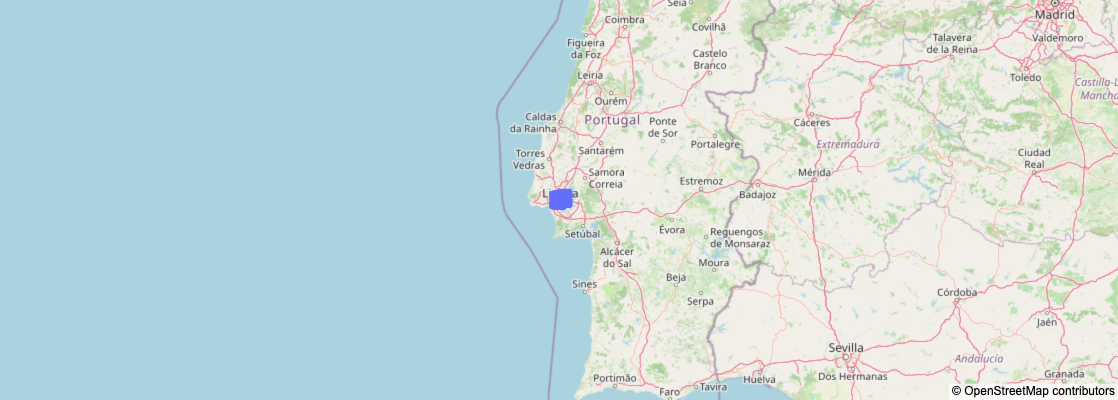

In [46]:
fig = px.scatter_mapbox(ci, lat="latitude", lon="longitude", hover_name="customer_name",
                        zoom=6, height=400)
fig.update_layout(mapbox_style="open-street-map", margin = dict(l=0,r=0,t=0,b=0))
fig.show()

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b> 2.DATA CLEANING</b></h3>

In [17]:
ci_clean = ci.copy()

print("Initial shape:", ci_clean.shape)

Initial shape: (33038, 24)


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b>2.1 Detecting Invalid Future Years in Dataset</b></h3>

In [18]:
current_year = pd.Timestamp.now().year
print("Current year:", current_year)

Current year: 2026


In [19]:
# Check invalid values BEFORE fixing
invalid_years = ci_clean[ci_clean['year_first_transaction'] > current_year]
print("\nInvalid future years found:")
display(invalid_years['year_first_transaction'].unique())


Invalid future years found:


array([2029., 2028., 2027.])

In [20]:
invalid_years_rows = utils.get_invalid_years(ci_clean)

if not invalid_years_rows.empty:
    print(f"Future years detected: {invalid_years_rows['year_first_transaction'].unique()}")
    display(invalid_years_rows.head())

Future years detected: [2029. 2028. 2027.]


,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
customer_id,,,,,,,,,,,,,,,,,,,,,,,,
25,Phd. Tom Fisher,male,03/17/2001 10:08 AM,0.0,0.0,NaN,2.0,8829.0,345.0,8.0,NaN,121.0,1657.0,1028.0,758.0,91.0,475.0,44.0,61.0,0.653237,2029.0,1.0,38.707590,-9.161818
37,Phd. Alonzo Crossan,male,09/29/2000 07:54 PM,1.0,1.0,0.0,5.0,25539.0,1089.0,7.0,907.0,1681.0,896.0,1153.0,962.0,1205.0,344.0,329.0,330.0,-0.184820,2028.0,1.0,38.729700,-9.196585
82,Msc. Heather Howie,female,09/25/2001 01:21 AM,0.0,0.0,0.0,2.0,8073.0,1372.0,8.0,123.0,304.0,1326.0,367.0,259.0,237.0,441.0,171.0,49.0,0.609053,2029.0,1.0,38.756427,-9.162594
115,Toni Sultan,female,03/14/1999 10:40 PM,1.0,1.0,2.0,1.0,17941.0,16101.0,23.0,268.0,596.0,1422.0,700.0,839.0,197.0,1409.0,294.0,161.0,0.414479,2027.0,1.0,38.722565,-9.149736
141,Bsc. Evelyn Hoffman,female,01/13/2000 07:00 AM,0.0,0.0,0.0,2.0,11257.0,412.0,9.0,1636.0,485.0,103.0,99.0,85.0,1846.0,115.0,14.0,191.0,0.304802,2028.0,1.0,38.754510,-9.183423


In [21]:
# Apply correction
ci_clean['year_first_transaction'] = ci_clean['year_first_transaction'].clip(upper=current_year)

In [22]:
# Validate AFTER fixing
print("\nMax year after correction:", ci_clean['year_first_transaction'].max())


Max year after correction: 2026.0


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b>2.2 Detecting Features with Negative Values</b></h3>

In [23]:
negative_values = ci_clean.select_dtypes(include=['number']).lt(0).any()
negative_values

kids_home                                  False
teens_home                                 False
number_complaints                          False
distinct_stores_visited                    False
lifetime_spend_groceries                   False
lifetime_spend_electronics                 False
typical_hour                               False
lifetime_spend_vegetables                  False
lifetime_spend_nonalcohol_drinks           False
lifetime_spend_alcohol_drinks              False
lifetime_spend_meat                        False
lifetime_spend_fish                        False
lifetime_spend_hygiene                     False
lifetime_spend_videogames                  False
lifetime_spend_petfood                     False
lifetime_total_distinct_products           False
percentage_of_products_bought_promotion     True
year_first_transaction                     False
loyalty_card_number                        False
latitude                                   False
longitude           

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b>2.3 Fix Negative Percentages</b></h3>

In [24]:
negative_values = ci_clean[ci_clean['percentage_of_products_bought_promotion'] < 0]
print("Negative values found:")
display(negative_values['percentage_of_products_bought_promotion'].head())

Negative values found:


customer_id
12   -0.131176
35   -0.025524
37   -0.184820
81   -0.217805
87   -0.022180
Name: percentage_of_products_bought_promotion, dtype: float64

In [25]:
ci_clean['percentage_of_products_bought_promotion'] = ci_clean[
    'percentage_of_products_bought_promotion'
].clip(lower=0)

In [26]:
print("\nMinimum value after correction:")
print(ci_clean['percentage_of_products_bought_promotion'].min())


Minimum value after correction:
0.0


In [27]:
print("Maximum value:")
print(ci_clean['percentage_of_products_bought_promotion'].max())

Maximum value:
1.0


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b> 2.4 Fix Columns Data Types</b></h3>

In [28]:
ci_clean['customer_birthdate'] = pd.to_datetime(ci_clean['customer_birthdate'], format = '%m/%d/%Y %I:%M %p')

In [29]:
int_columns = [
    'kids_home', 'teens_home', 'number_complaints',
    'distinct_stores_visited', 'typical_hour',
    'lifetime_total_distinct_products', 'year_first_transaction'
]

for col in int_columns:
    if col in ci_clean.columns:
        ci_clean[col] = pd.to_numeric(ci_clean[col], errors='coerce')

In [30]:
ci_clean['loyalty_card_number']

customer_id
3        1.0
4        1.0
5        NaN
7        1.0
8        1.0
        ... 
39996    NaN
39997    NaN
39998    NaN
39999    NaN
40000    NaN
Name: loyalty_card_number, Length: 33038, dtype: float64

In [31]:
print("Updated data types:")
display(ci_clean.dtypes)

Updated data types:


customer_name                                      object
customer_gender                                    object
customer_birthdate                         datetime64[ns]
kids_home                                         float64
teens_home                                        float64
number_complaints                                 float64
distinct_stores_visited                           float64
lifetime_spend_groceries                          float64
lifetime_spend_electronics                        float64
typical_hour                                      float64
lifetime_spend_vegetables                         float64
lifetime_spend_nonalcohol_drinks                  float64
lifetime_spend_alcohol_drinks                     float64
lifetime_spend_meat                               float64
lifetime_spend_fish                               float64
lifetime_spend_hygiene                            float64
lifetime_spend_videogames                         float64
lifetime_spend

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b> 2.5 Missing Values Treatment</h3>

In [32]:
print("Missing values BEFORE imputation:")
display(ci_clean.isna().sum())

Missing values BEFORE imputation:


customer_name                                  0
customer_gender                                0
customer_birthdate                           165
kids_home                                    330
teens_home                                   330
number_complaints                            661
distinct_stores_visited                      330
lifetime_spend_groceries                       0
lifetime_spend_electronics                   661
typical_hour                                 661
lifetime_spend_vegetables                    661
lifetime_spend_nonalcohol_drinks               0
lifetime_spend_alcohol_drinks                330
lifetime_spend_meat                          661
lifetime_spend_fish                          991
lifetime_spend_hygiene                       330
lifetime_spend_videogames                    661
lifetime_spend_petfood                       661
lifetime_total_distinct_products               0
percentage_of_products_bought_promotion      330
year_first_transacti

! pensei que aqui podiamos ver a idade da pessoa no kis_home etc tipo <25 meter zero, entre 25 e 40 2 kids, depois dois teens ou assumir só zero

In [33]:
zero_cols = ['kids_home', 'teens_home', 'number_complaints']

for col in zero_cols:
    if col in ci_clean.columns:
        ci_clean[col] = ci_clean[col].fillna(0)

In [34]:
ci_clean.rename(columns={'loyalty_card_number': 'customer_loyalty_flag'}, inplace=True)

ci_clean['customer_loyalty_flag'] = ci_clean['customer_loyalty_flag'].fillna(0).apply(lambda x: 1 if x != 0 else 0)

print(ci_clean['customer_loyalty_flag'].value_counts())

customer_loyalty_flag
1    19932
0    13106
Name: count, dtype: int64


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b> 4.Aggregation Feature Engineering</h3>

In [35]:
ci_clean.rename(columns = {'customer_birthdate': 'customer_age'}, inplace = True)
ci_clean['customer_age'] = datetime.now().year - ci_clean['customer_age'].dt.year

In [36]:
ci_clean[['education_level', 'customer_name_clean']] = ci.apply(utils.get_education_info, axis=1)

display(ci_clean[['customer_name', 'education_level', 'customer_name_clean']].head())

,customer_name,education_level,customer_name_clean
customer_id,,,
3,Bsc. Crystal Kitchens,1,Crystal Kitchens
4,Bsc. Glenda Bauman,1,Glenda Bauman
5,Msc. Antonio Campbell,2,Antonio Campbell
7,John Kelling,0,John Kelling
8,Arthur Dematteo,0,Arthur Dematteo


In [38]:
ci_clean['is_male'] = ci_clean['customer_gender'].map({'male': 1, 'female': 0})
display(ci_clean[['customer_gender', 'is_male']].head())

,customer_gender,is_male
customer_id,,
3,female,0
4,female,0
5,male,1
7,male,1
8,male,1


In [39]:
ci_clean.drop(columns=['customer_gender'], inplace=True)

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b> 6.Transformation Feature Engineering</h3>

In [40]:
# A. Create Tenure (Years as a customer)
ci_clean['tenure'] = current_year - ci_clean['year_first_transaction']

# B. Aggregate Spending: Total Lifetime Spend 
spend_cols = [col for col in ci_clean.columns if 'lifetime_spend' in col]
ci_clean['total_spend'] = ci_clean[spend_cols].sum(axis=1)

# C. Household Dynamics: Total Children
ci_clean['total_children'] = ci_clean['kids_home'] +ci_clean['teens_home']

# D. Create a technology spend
ci_clean["lifetime_spend_techonology"] = ci_clean["lifetime_spend_electronics"] + ci_clean["lifetime_spend_videogames"]
ci_clean.drop(columns=["lifetime_spend_electronics", "lifetime_spend_videogames"], inplace=True)

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b> 5. Missing Values Imputation</h3>

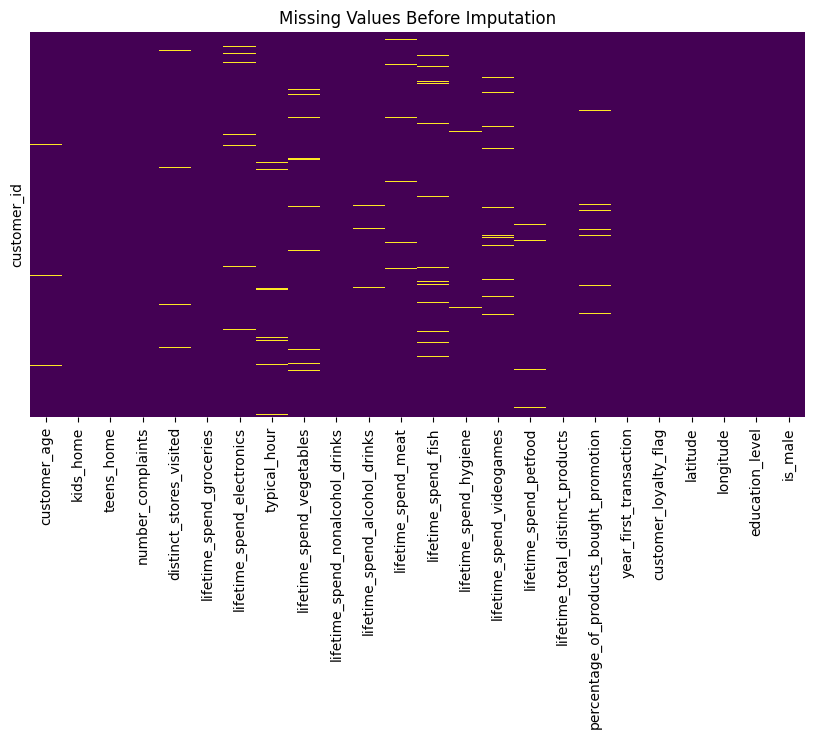

,Missing Count,Percentage (%)
lifetime_spend_fish,991,2.999576
lifetime_spend_electronics,661,2.000726
typical_hour,661,2.000726
lifetime_spend_vegetables,661,2.000726
lifetime_spend_meat,661,2.000726
lifetime_spend_videogames,661,2.000726
lifetime_spend_petfood,661,2.000726
distinct_stores_visited,330,0.998850
lifetime_spend_alcohol_drinks,330,0.998850
lifetime_spend_hygiene,330,0.998850


Remaining missing values: 0


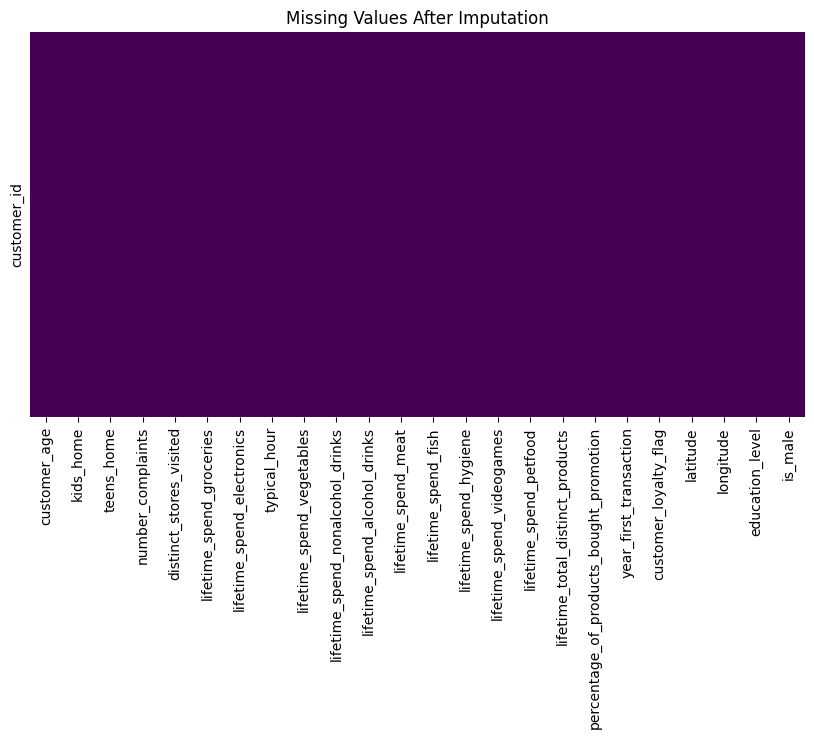

In [43]:
utils.plot_missing_heatmap(ci_clean, "Missing Values Before Imputation")
display(utils.get_missing_report(ci_clean))

ci_clean = utils.apply_knn_imputation(ci_clean, n_neighbors=5)

int_vars = ['kids_home', 'teens_home', 'number_complaints', 'distinct_stores_visited']
for var in int_vars:
    if var in ci_clean.columns:
        ci_clean[var] = ci_clean[var].round().astype(int)

print("Remaining missing values:", ci_clean.isnull().sum().sum())
utils.plot_missing_heatmap(ci_clean, "Missing Values After Imputation")

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b> 7. Outliers Treatment</h3>

In [41]:
spend_cols = [col for col in ci_clean.columns if 'lifetime_spend' in col]
other_numeric = ['customer_age', 'distinct_stores_visited', 'lifetime_total_distinct_products']

cols_to_treat = spend_cols + other_numeric

ci_clean = utils.handle_extreme_outliers(ci_clean, cols_to_treat, strategy='cap')

print(f"Extreme outliers treated in {len(cols_to_treat)} columns.")

Extreme outliers treated in 13 columns.



<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b> 8. Multivariate Analysis: Feature Correlation</h3>

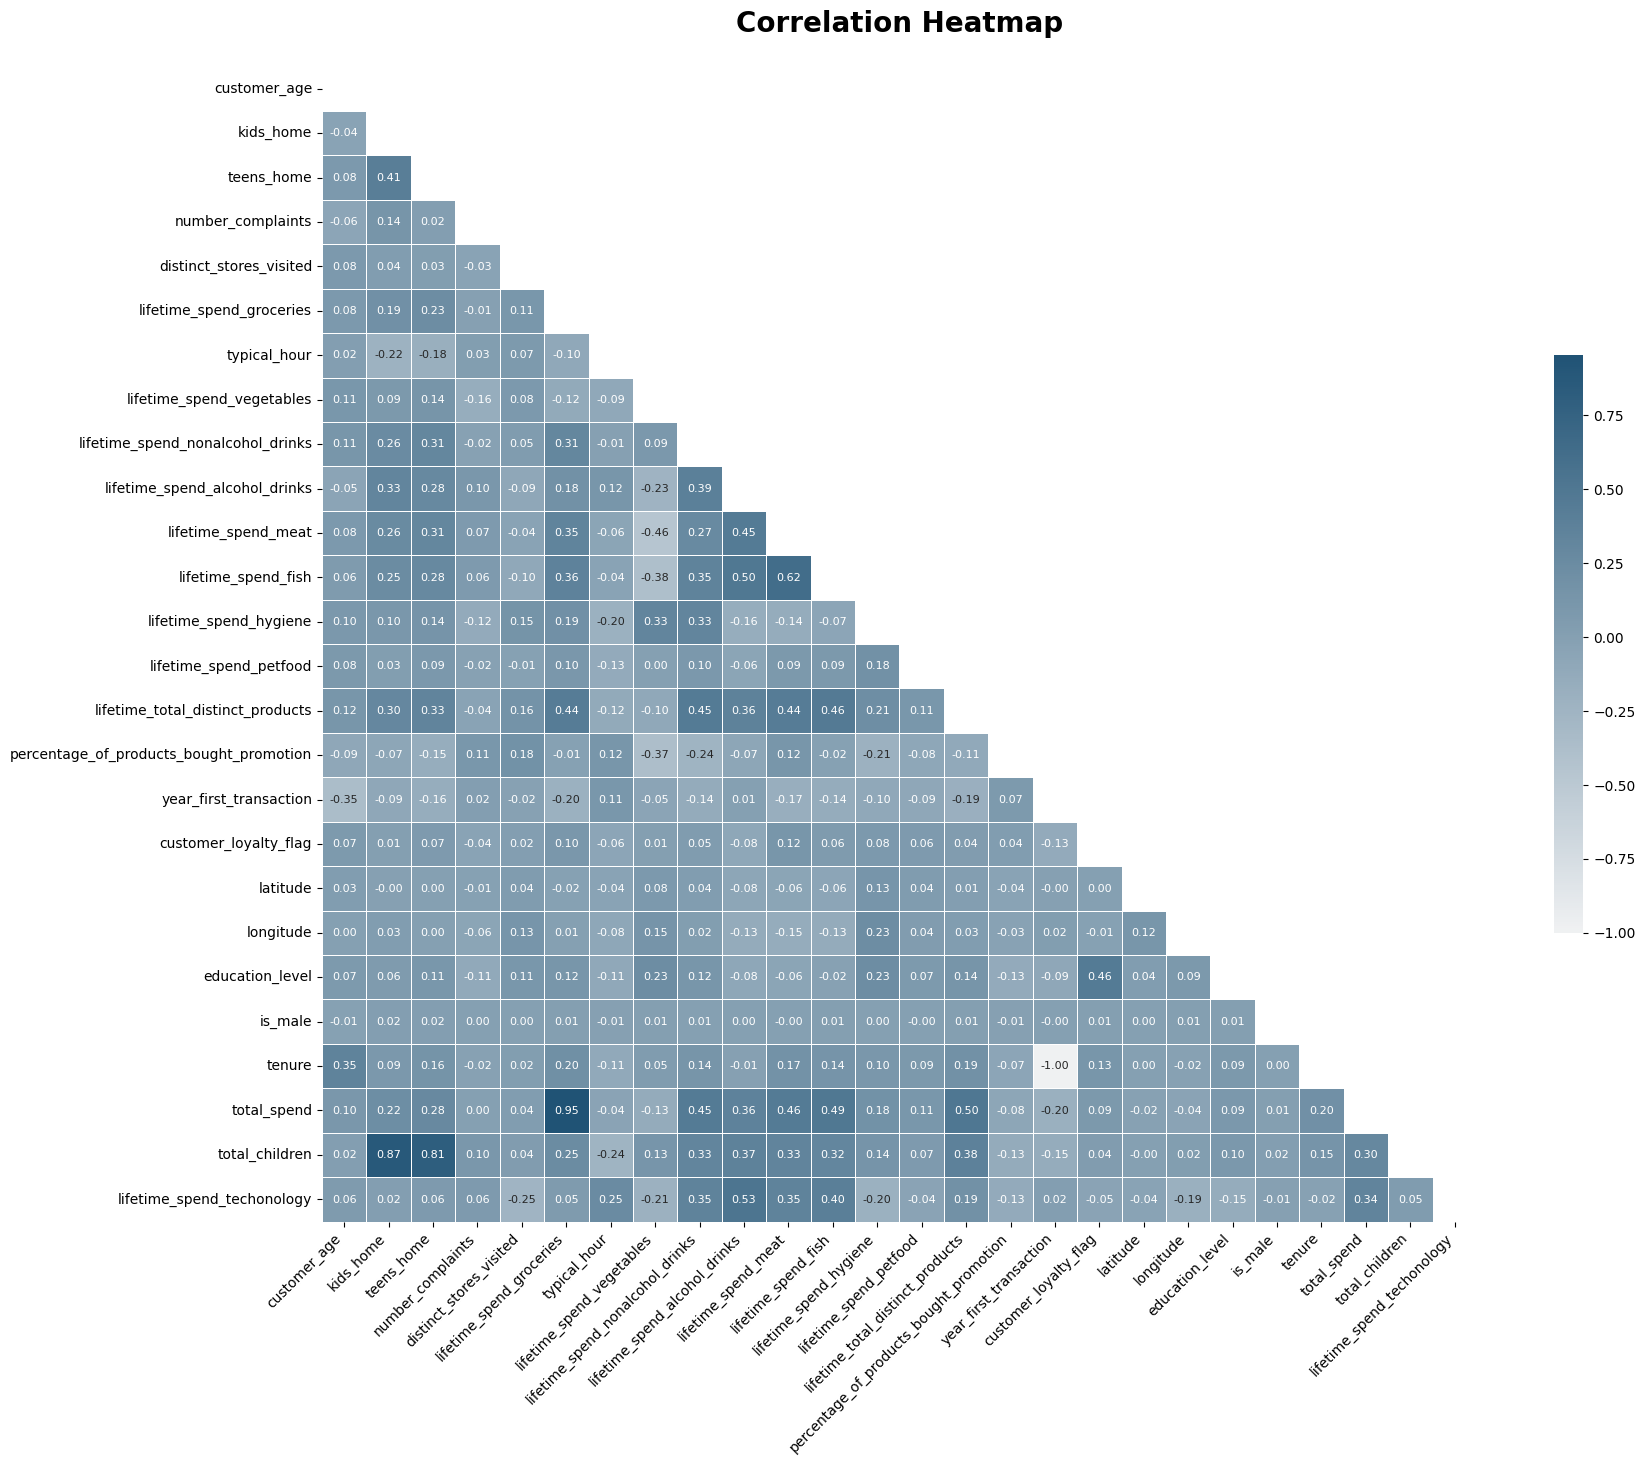

In [45]:
# Select only relevant columns (excluding IDs) for a cleaner map
cols_to_corr = ci_clean.select_dtypes(include=np.number).columns.tolist()
if 'loyalty_card_number' in cols_to_corr: cols_to_corr.remove('loyalty_card_number')

# Call the function from utils
utils.cor_heatmap(ci_clean[cols_to_corr].corr())